# Preload Packages

In [20]:
# Limit number of cores
import os
os.nice(19)
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"

# Create logger
import logging
logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)

if not logger.hasHandlers():
    ch = logging.StreamHandler()
    formatter = logging.Formatter('%(asctime)s - %(name)s - %(levelname)s - %(message)s')
    ch.setFormatter(formatter)
    logger.addHandler(ch)

### Own packages

In [21]:
import pyccl as ccl
import numpy as np
import matplotlib.pyplot as plt
import h5py

rootpath = '/home/dneup16/leiden_phd/scripts/GNAT'
if rootpath not in os.sys.path:
    os.sys.path.append(rootpath)

import src.galaxy_alignment_prediction_tool.multipoles
import src.galaxy_alignment_prediction_tool.powerspectrum
import src.galaxy_alignment_prediction_tool.projections
import src.galaxy_alignment_prediction_tool.fitter
import src.galaxy_alignment_prediction_tool.utils
import src.galaxy_alignment_prediction_tool.predictor

# Reload to update changes
import importlib
importlib.reload(src.galaxy_alignment_prediction_tool.multipoles)
importlib.reload(src.galaxy_alignment_prediction_tool.powerspectrum)
importlib.reload(src.galaxy_alignment_prediction_tool.projections)
importlib.reload(src.galaxy_alignment_prediction_tool.fitter)
importlib.reload(src.galaxy_alignment_prediction_tool.utils)
importlib.reload(src.galaxy_alignment_prediction_tool.predictor)

from src.galaxy_alignment_prediction_tool.multipoles import multipoles
from src.galaxy_alignment_prediction_tool.powerspectrum import powerSpectrum
from src.galaxy_alignment_prediction_tool.projections import projections
from src.galaxy_alignment_prediction_tool.fitter import fitter
from src.galaxy_alignment_prediction_tool.utils import ioUtils
from src.galaxy_alignment_prediction_tool.predictor import galaxyAlignmentPredictor

# Initialise classes
fitterHandler = fitter(logger=logger)
ioUtilsHandler = ioUtils(logger=logger)
powerSpectrumHandler = powerSpectrum()
multipolesHandler = multipoles()
projectionsHandler = projections()

# Test individual predictor functions

In [26]:
cosmo_params = {
    'h': 0.67,
    'Omega_c': 0.25,
    'Omega_b': 0.05,
    'n_s': 0.96,
    'sigma8': 0.8,
}
ccl_cosmo = ccl.Cosmology(**cosmo_params)
redshift_list = np.array([0., 0.5, 1., 1.5])
k_input_single = np.geomspace(1e-5, 500, 1000)
pk_input = np.zeros((len(k_input_single), 2, len(redshift_list)))
k_input = np.tile(k_input_single, (len(redshift_list), 2, 1)).T

for i, redshift in enumerate(redshift_list):
    pkmm_ccl = powerSpectrumHandler.ccl_power_spectrum(
        cosmo=ccl_cosmo,
        k_input=k_input_single,
        redshift=redshift,
        pk_type='nonlinear_matter'
    )

    # Initialise power spectra
    pkgp = powerSpectrumHandler.convert_pk_matter_to_pk_gplus(
        pk_matter=pkmm_ccl,
        cosmo=ccl_cosmo,
        redshift=redshift
    )
    pkgg = powerSpectrumHandler.convert_pk_matter_to_pk_gg(
        pk_matter=pkmm_ccl,
        cosmo=ccl_cosmo,
        redshift=redshift,
        )

    pk_input[:, 0, i] = pkgg
    pk_input[:, 1, i] = pkgp

In [27]:
predictor = galaxyAlignmentPredictor(
    cosmology=ccl_cosmo,
    redshift_list=redshift_list
)

In [28]:
np.shape(k_input)
for idx_z in range(len(redshift_list)-1):
    for idx_meas in range(2):
        assert (k_input[:, idx_meas, idx_z] == k_input[:, idx_meas, idx_z+1]).all()

In [ ]:
predictor.initialise_power_spectra(
    k_input=k_input,
    pk_input=pk_input,
    bessel_order=np.array([0, 2])
)

In [29]:
rhocrit = ccl.physical_constants.RHO_CRITICAL # M_sun/h (Mpc/h)^-3
C1 = 5e-14  # in (h^2 M_sun Mpc^-3)^-1
C1rhocrit = C1 * rhocrit
C1rhocrit

0.013876831360184281

# Test joint predictor functions

In [23]:
cosmo_params = {
    'h': 0.67,
    'Omega_c': 0.25,
    'Omega_b': 0.05,
    'n_s': 0.96,
    'sigma8': 0.8,
}
ccl_cosmo = ccl.Cosmology(**cosmo_params)
redshift_list = np.arange(0., 2.1, 0.25)
predictor = galaxyAlignmentPredictor(
    cosmology=ccl_cosmo,
    redshift_list=redshift_list,
    logger=logger,
)

predictor.initialise_gp_gg_power_spectra_from_ccl(
    k_bounds=[1e-6, 1000],
    n_k=5000,
)
rp_array = np.geomspace(0.1, 200, 500)/predictor.cosmology['h']  # Mpc
r_array = np.geomspace(0.1, 200, 500)/predictor.cosmology['h']  # Mpc
pi_max = 50/predictor.cosmology['h']  # Mpc
predictor.calculate_estimators(
    rp_support=rp_array,
    beta_shape=0.,
    beta_density=0.,
    pi_max=pi_max,
)

2026-01-21 14:09:28,018 - __main__ - INFO - Initialising power spectrum splines for each redshift
100%|██████████| 9/9 [00:00<00:00, 4923.53it/s]
2026-01-21 14:09:28,022 - __main__ - INFO - Done. Splines stored in self.pk_splines_list
2026-01-21 14:09:28,023 - __main__ - INFO - Calculating estimators for each redshift and power spectrum type
100%|██████████| 9/9 [00:00<00:00, 14.73it/s]
2026-01-21 14:09:28,636 - __main__ - INFO - Done calculating estimators. Results stored in self.multipole_splines and self.projection_splines


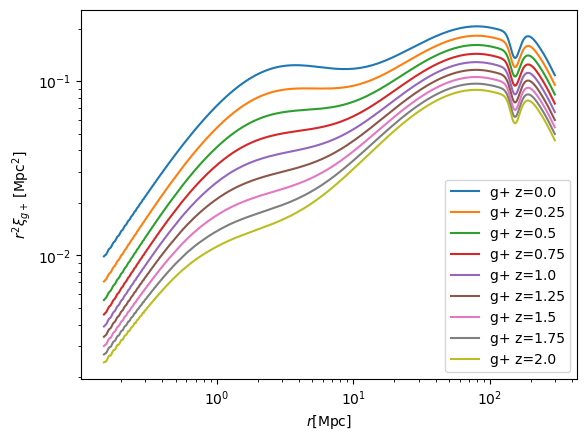

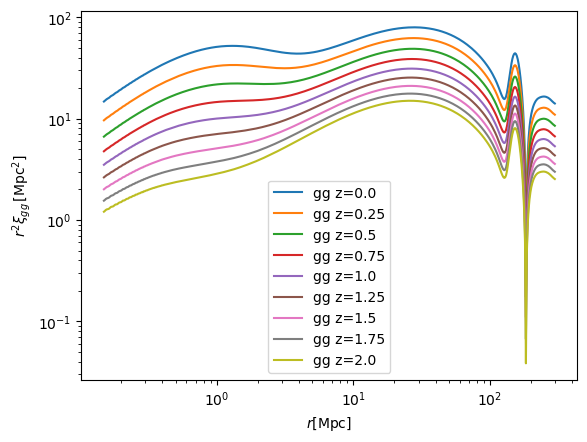

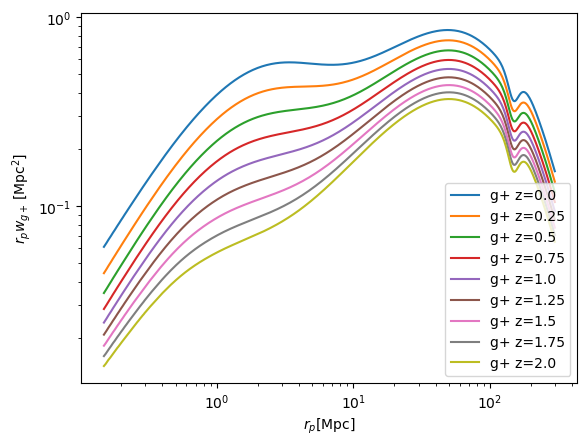

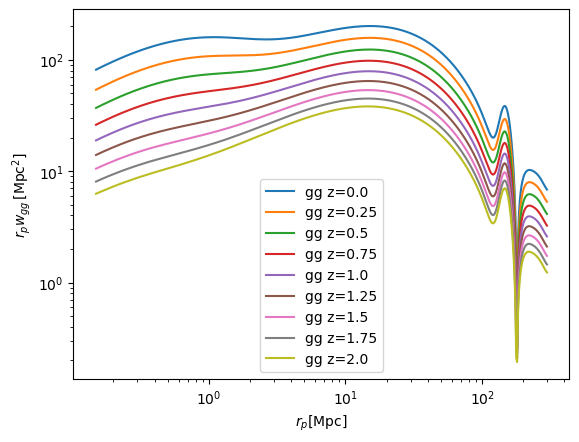

In [25]:
w_arr, xi_arr = predictor.return_all_estimators_as_arrays(
    rp_support=rp_array,
    r_support=r_array,
)

xi_gp = xi_arr[:, 0, :]
xi_gg = xi_arr[:, 1, :]
w_gp = w_arr[:, 0, :]
w_gg = w_arr[:, 1, :]

for i_z, z in enumerate(redshift_list):
    plt.loglog(r_array, r_array**2*xi_gp[:, i_z], label=f"g+ z={z}")
plt.xlabel(r"$r [\mathrm{Mpc}]$")
plt.ylabel(r"$r^2 \xi_{g+} \, [\mathrm{Mpc}^2]$")
plt.legend()
plt.show()
plt.close()

for i_z, z in enumerate(redshift_list):
    plt.loglog(r_array, np.abs(r_array**2*xi_gg[:, i_z]), label=f"gg z={z}")
plt.xlabel(r"$r [\mathrm{Mpc}]$")
plt.ylabel(r"$r^2 \xi_{gg} \, [\mathrm{Mpc}^2]$")
plt.legend()
plt.show()
plt.close()

for i_z, z in enumerate(redshift_list):
    plt.loglog(rp_array, r_array*w_gp[:, i_z], label=f"g+ z={z}")
plt.xlabel(r"$r_p [\mathrm{Mpc}]$")
plt.ylabel(r"$r_p w_{g+} \, [\mathrm{Mpc}^2]$")
plt.legend()
plt.show()
plt.close()

for i_z, z in enumerate(redshift_list):
    plt.loglog(rp_array, np.abs(r_array*w_gg[:, i_z]), label=f"gg z={z}")
plt.xlabel(r"$r_p [\mathrm{Mpc}]$")
plt.ylabel(r"$r_p w_{gg} \, [\mathrm{Mpc}^2]$")
plt.legend()
plt.show()
plt.close()

